Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

MIMIC-III es una base de datos extensa y de libre acceso que contiene datos de salud anonimizados de más de 40 000 pacientes ingresados ​​en unidades de cuidados intensivos del Beth Israel Deaconess Medical Center entre 2001 y 2012 [1]. La base de datos clínica MIMIC-III está disponible en PhysioNet (doi: 10.13026/C2XW26 ). Aunque anonimizada, MIMIC-III contiene información detallada sobre la atención de pacientes reales y, por lo tanto, requiere acreditación para acceder a ella. Para que los investigadores puedan determinar si la base de datos es adecuada para su trabajo, hemos creado manualmente un subconjunto de demostración que contiene información de 100 pacientes también presentes en la base de datos clínica MIMIC-III. Cabe destacar que el conjunto de datos de demostración no incluye notas de texto libre.



In [21]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [22]:
# Cargamos las dos tablas principales
df_call = pd.read_csv('CALLOUT.csv')
df_chart = pd.read_csv('CHARTEVENTS.csv', nrows=50000) # Muestra para que no sea lento

# Unimos las tablas para tener datos del paciente y sus signos
df_mimic = pd.merge(df_call, df_chart[['subject_id', 'hadm_id', 'itemid', 'valuenum']], on=['subject_id', 'hadm_id'], how='inner')

# LIMPIEZA PREVENTIVA: Borramos columnas 100% vacías para que el KNN no falle
df_mimic = df_mimic.dropna(axis=1, how='all')

print(f"Dataset 2 unido. Tamaño: {df_mimic.shape}")

Dataset 2 unido. Tamaño: (33016, 26)


In [23]:
# Verificar nulos
print("\n--- Conteo de Nulos en MIMIC Unido ---")
nulos = df_mimic.isnull().sum()
print(nulos[nulos > 0])

print(f"\nTotal general de nulos: {df_mimic.isnull().sum().sum()}")


--- Conteo de Nulos en MIMIC Unido ---
submit_careunit           28693
discharge_wardid           3418
firstreservationtime       7794
currentreservationtime    31919
dtype: int64

Total general de nulos: 71824


In [24]:
# 1. Identificar y borrar columnas que están 100% vacías (Sin esto el KNN falla)
df_mimic = df_mimic.dropna(axis=1, how='all')

In [25]:
# El KNN no puede procesar palabras, así que convertimos todo a números primero.
le = LabelEncoder()
for col in df_mimic.columns:
    if df_mimic[col].dtype == 'object':
        df_mimic[col] = le.fit_transform(df_mimic[col].astype(str))
print("\n¡Letras convertidas a números con éxito!")


¡Letras convertidas a números con éxito!


In [26]:
# 1. Calculamos la media (mu) y la desviación estándar (sigma) de cada columna
mu = np.mean(df_mimic, axis=0)
sigma = np.std(df_mimic, axis=0)

# 2. Aplicamos la fórmula: (x - media) / desviación_estándar
# Agregamos un valor muy pequeño (1e-8) para evitar la división por cero
df_scaled = (df_mimic - mu) / (sigma + 1e-8)

print("--- Normalización Z-Score Manual Completada ---")
print(df_scaled.describe().loc[['mean', 'std']]) # Debería mostrar media ~0 y std ~1

--- Normalización Z-Score Manual Completada ---
            row_id    subject_id       hadm_id  submit_wardid  \
mean  4.453159e-15  1.013216e-15  5.440550e-16  -2.048815e-16   
std   1.000015e+00  1.000015e+00  1.000015e+00   1.000015e+00   

      submit_careunit   curr_wardid  curr_careunit  callout_wardid  \
mean     1.076058e-16 -1.670042e-16   6.585476e-17   -4.368796e-17   
std      1.000015e+00  1.000015e+00   1.000015e+00    1.000015e+00   

      callout_service  request_tele  ...  discharge_wardid  \
mean    -2.091857e-16  3.959894e-17  ...     -9.986681e-17   
std      1.000015e+00  1.000015e+00  ...      1.000017e+00   

      acknowledge_status    createtime    updatetime  acknowledgetime  \
mean                 0.0 -6.886772e-17 -6.886772e-17    -6.886772e-17   
std                  0.0  1.000015e+00  1.000015e+00     1.000015e+00   

       outcometime  firstreservationtime  currentreservationtime  \
mean -6.886772e-17         -7.919788e-17           -2.341503e-16   
st

In [27]:
knn = KNNImputer(n_neighbors=5)
# Aquí generamos el df_final definitivo
data_imputed = knn.fit_transform(df_scaled)
df_final = pd.DataFrame(data_imputed, columns=df_scaled.columns)

print(f"\n¡Éxito! Nulos finales: {df_final.isnull().sum().sum()}")


¡Éxito! Nulos finales: 0


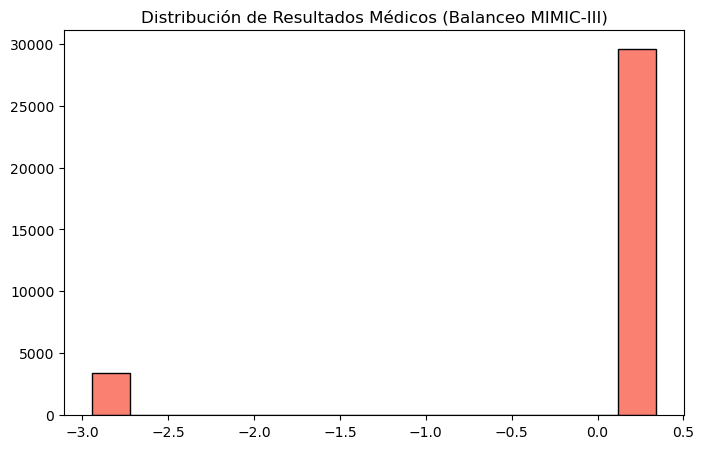

In [28]:
# En MIMIC usamos 'callout_outcome' como nuestra variable de interés
plt.figure(figsize=(8, 5))
plt.hist(df_final['callout_outcome'], bins=15, color='salmon', edgecolor='black')
plt.title('Distribución de Resultados Médicos (Balanceo MIMIC-III)')
plt.show()

In [32]:
# Preparamos los insumos para el entrenamiento
X = df_final.drop('callout_outcome', axis=1).values
y = df_final['callout_outcome'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Entrenamiento (X_train): {X_train.shape}")
print(f"Prueba (X_test): {X_test.shape}")

Entrenamiento (X_train): (24762, 25)
Prueba (X_test): (8254, 25)


In [31]:
def train_con_historial(X, y, lr=0.01, epochs=1000, lambd=0.1, is_class=True):
    m, n = X.shape
    w = np.zeros((n, 1))
    b = 0
    loss_history = [] # <--- Aquí guardaremos la evolución del error

    for i in range(epochs):
        # 1. Predicción
        z = np.dot(X, w) + b
        y_pred = sigmoid(z) if is_class else z
        
        # 2. Cálculo del Costo (Log-Loss para clase, MSE para regresión)
        if is_class:
            # Evitamos log(0) con un epsilon pequeño
            epsilon = 1e-15
            y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
            costo = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        else:
            costo = np.mean((y_pred - y)**2)
            
        # Añadimos la penalización L2 al costo para el reporte
        costo_reg = costo + (lambd / (2 * m)) * np.sum(np.square(w))
        loss_history.append(costo_reg)

        # 3. Gradientes y Actualización
        error = y_pred - y
        dw = (1/m) * np.dot(X.T, error) + (lambd/m) * w
        db = (1/m) * np.sum(error)
        w -= lr * dw
        b -= lr * db
        
    return w, b, loss_history

# Ejecutamos el entrenamiento
weights, bias, historial = train_con_historial(X_train, y_train, lr=0.05, epochs=1500, lambd=0.1)

NameError: name 'sigmoid' is not defined

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(historial, color='firebrick', linewidth=2)
plt.title('Curva de Aprendizaje (Función de Costo)')
plt.xlabel('Épocas (Iteraciones)')
plt.ylabel('Costo (Loss)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()